# M2.Ex1: Advertising Revenue

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [2]:
import pandas as pd
import sklearn

## Advertising Dataset

The Advertising Dataset is a fundamental resource in statistical learning and regression analysis. It is primarily known for its use in the first chapter of the seminal textbook "An Introduction to Statistical Learning" (ISLR) by Gareth James, Daniela Witten, Trevor Hastie, and Robert Tibshirani.

The dataset is used to illustrate the relationship between advertising budgets across different media and the resulting product sales.

- Features: `3` numerical
- Target: `sales` of the product (in thousands of units).
- Size: `200` samples.
- Source: [Advertising Dataset](https://www.statlearning.com/s/Advertising.csv)

### Step 1. Load the data

In [ ]:
adv = pd.read_csv("../../../datasets/advertising.csv")
adv

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


### Step 2.a Assign variables `X` to the features and `y` to the target

In [ ]:
X = adv[['TV', 'Radio', 'Newspaper']]
y = adv["Sales"]

### Step 2.b print the type of each

In [6]:
X.dtypes

TV           float64
Radio        float64
Newspaper    float64
dtype: object

In [7]:
y.dtype

dtype('float64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

- Target `Sales` is numerical
- Thus it is a regression task

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [8]:
# Data Matrix
X.shape

(200, 3)

In [9]:
y.shape

(200,)

### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [10]:
X.describe()

,TV,Radio,Newspaper
count,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000
std,85.854236,14.846809,21.778621
min,0.700000,0.000000,0.300000
25%,74.375000,9.975000,12.750000
50%,149.750000,22.900000,25.750000
75%,218.825000,36.525000,45.100000
max,296.400000,49.600000,114.000000


<Axes: xlabel='Sales', ylabel='Count'>

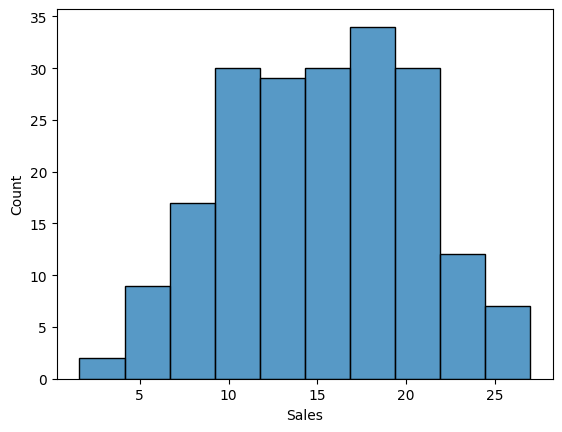

In [12]:
import seaborn as sns

sns.histplot(y)

### Step 5. How much difference do you see in the scale of each feature? (calculate the featre-wise range differences)

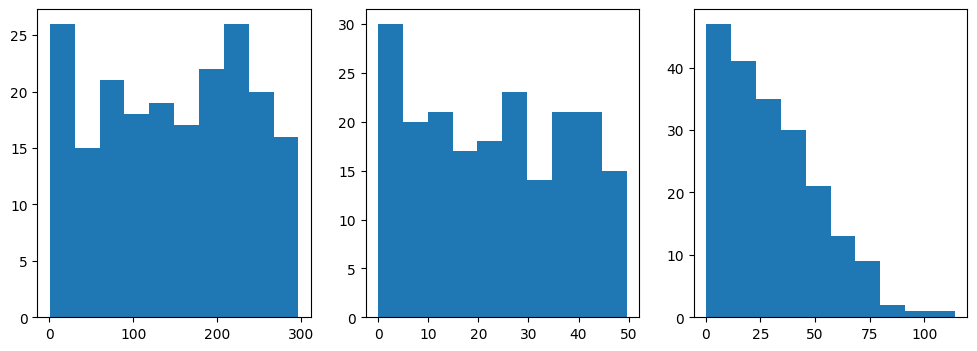

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(X['TV'])
ax[1].hist(X['Radio'])
ax[2].hist(X['Newspaper'])
plt.show()

### Step 6.a Plot each of the features vs the target

Hint use this: `sns.pairplot()`

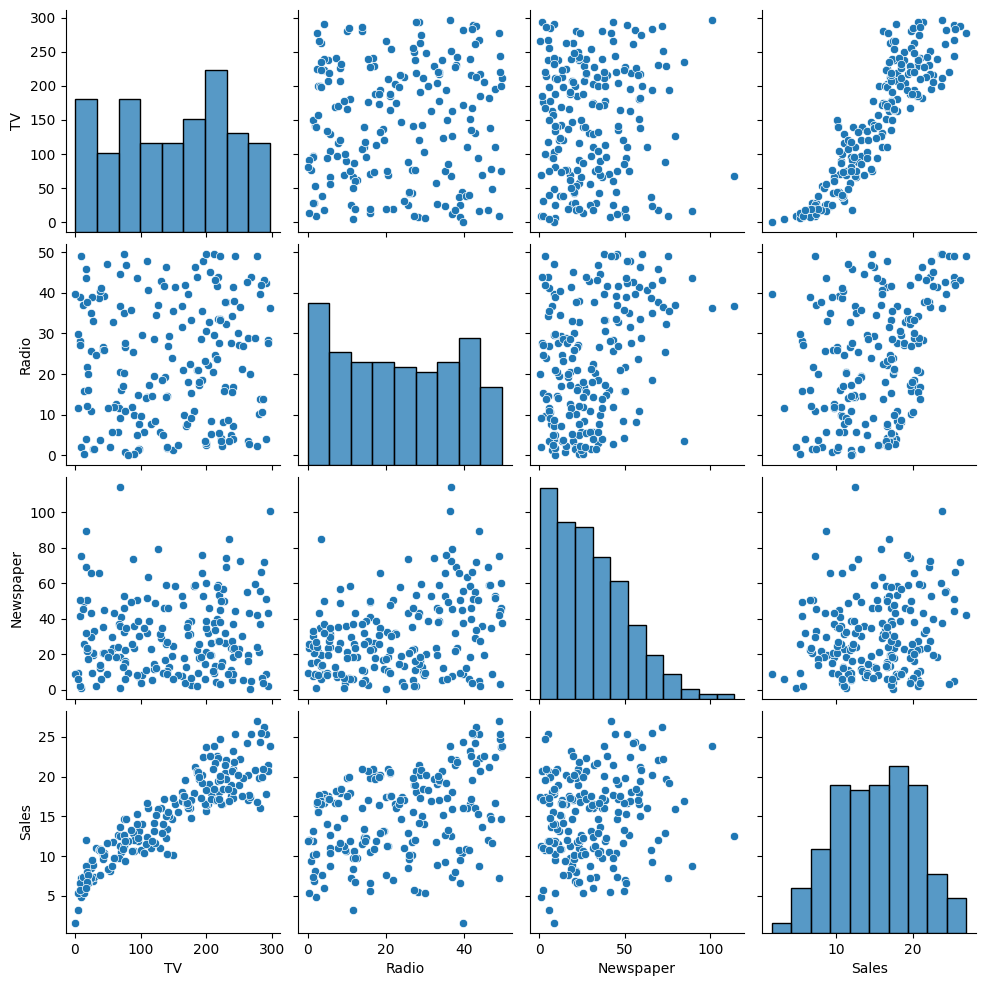

In [ ]:
sns.pairplot(adv)

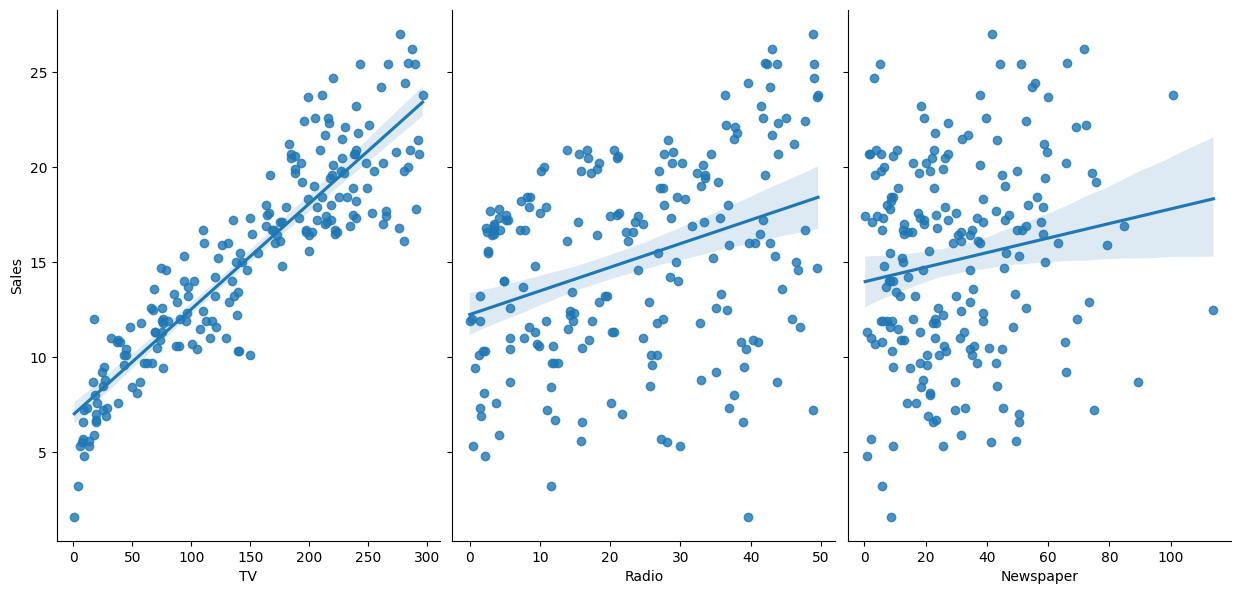

In [ ]:
sns.pairplot(
    adv,
    x_vars=['TV','Radio','Newspaper'],
    y_vars='Sales',
    height=6,
    aspect=0.7,
    kind='reg'
)

### Step 6.b What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=TV` and `y=Sales`
2. `x=Radio` and `y=Sales`
3. `x=Newspaper` and `y=Sales`

Answer: TV > Radio > Newspaper (all increasing).

### Step 7. Define the pipeline with pre-processing steps

Make a Pipeline of three sequential steps:

1. transformer: `SimpleImputer` (to fill in missing values)
2. transformer: `StandardScaler` (to scale numerical features)
3. predictor: `LinearRegression` (to model the relationship)

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

predictor = LinearRegression()

In [16]:
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)

### Step 8. Split the dataset into train and test sets

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

### Step 9.a Fit the pipeline on the training set

In [19]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [ ]:
model = pipe[-1]

### Step 9.c how much spending on TV `$1,000` more, factor into Sales?

In [33]:
X.columns

Index(['TV', 'Radio', 'Newspaper'], dtype='str')

In [32]:
model.coef_

array([4.58720774, 1.48984025, 0.08791597])

In [42]:
print(f"Spending $1,000 more on TV, increases Sales by {model.coef_[0]:.2f} thousands.")

Spending $1,000 more on TV, increases Sales by 4.59 thousands.


### Step 9.d if we take `$5,000` away from Newspaper and put it in Radio how much difference does that make into Sales?

In [ ]:
diff = -(model.coef_[2] * 5) + (model.coef_[1] * 5)
print(f"Taking $5,000 away from Newspaper and putting it in Radio, increases Sales by {diff:.2f} thousands.")

Taking $5,000 away from Newspaper and putting it in Radio, increases Sales by 7.01 thousands.


### Step 9.e if we spend nothing at all on advertising, how much do we estimate our Sales to be?

In [46]:
print(f"If we spend nothing at all on advertising, we estimate our Sales to be {model.intercept_:.2f} thousands.")

If we spend nothing at all on advertising, we estimate our Sales to be 15.33 thousands.


### Step 9.f if we spend:

- 1 thousand on `TV` 
- 2 thousand on `Radio`
- 3 thousand on `Newspaper`

How much the model estimates our `Sales` to be?

In [47]:
model.predict([[1, 2, 3]])

array([23.16126114])

### Step 10. Evaluate the pipeline on the test set

In [50]:
score = pipe.score(X_test, y_test)
round(score, 2)

0.91

### Step 11. Define a `LinearRegression` model without the pre-processing steps, and compare it's score with the pipeline. Which one is better?

In [51]:
model_2 = LinearRegression()
model_2.fit(X_train, y_train)
score_2 = model_2.score(X_test, y_test)

In [52]:
print(f"Pipeline score: {score:.2f}")
print(f"LinearRegression score: {score_2:.2f}")

Pipeline score: 0.91
LinearRegression score: 0.91
